##Exemplo de um perceptron

Criando um dataset que simula a não lineariedade da operação XOR. Para isto, irei criar quatro grupos distintos de dados.

Operação XOR: A operação XOR (Exclusive OR) é uma operação lógica binária. Ela retorna verdadeiro (True ou 1) apenas se uma das entradas for verdadeira, mas não ambas. Se ambas as entradas forem falsas ou ambas forem verdadeiras, ela retorna falso (False ou 0).

In [ ]:
#Imports necessários
import numpy as np                          # carrega a biblioteca numpy para operações matriciais
from sklearn.preprocessing import StandardScaler  # importa o método Standard Scaler para a normalização (escalamento) dos dados
from sklearn.utils import shuffle    # metodo shuffle vai embaralhar os pontos gerados
from multiprocessing import cpu_count  #cpu_count define quantos núcles tem o computador - para usar paralelismo durante a execução do algoritmo
from sklearn.linear_model import Perceptron  #importa o modelo perceptron
from sklearn.model_selection import cross_val_score #utiliza o método cross validation para indicar a acurácia média do modelo
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation

In [ ]:
# Criando o dataset XOR


np.random.seed(1000)   # define a seed do random para que o experimento possa ser reproduzido

nb_samples = 1000              #serão criados 1000 pontos
nsb = int(nb_samples / 4)      #divididos em 4 grupos
X = np.zeros((nb_samples, 2))  #onde aqui definimos o tamanho do conjunto X (pontos) - 1000 pontos com 2 dimensões (coordenadas)
Y = np.zeros((nb_samples, ))   #e do Y (classes conjunto roxo = 1 ou conjunto amarelo = 0)

#vamos definir a pequena variação entre os pontos de cada conjunto
#coordenada 1, -1
X[0:nsb, :] = np.random.multivariate_normal([1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[0:nsb] = 0.0 # classe 0

#coordenada 1, 1
X[nsb:(2 * nsb), :] = np.random.multivariate_normal([1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[nsb:(2 * nsb)] = 1.0 #classe 1

#coordenada -1, 1
X[(2 * nsb):(3 * nsb), :] = np.random.multivariate_normal([-1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(2 * nsb):(3 * nsb)] = 0.0 #classe 0

#coordenada -1, -1
X[(3 * nsb):, :] = np.random.multivariate_normal([-1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(3 * nsb):] = 1.0 #classe 1

ss = StandardScaler()
X = ss.fit_transform(X) #normaliza os dados para a escala entre 0,1

X, Y = shuffle(X, Y, random_state=1000) # embaralha os dados

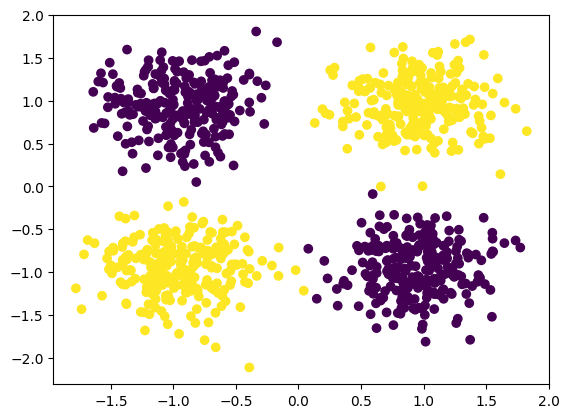

In [ ]:
#Exibindo dataset XOR
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

In [ ]:
#verificando a acurácia usando um perceptron


pc = Perceptron(penalty='l2', alpha=0.1, max_iter=1000, n_jobs=cpu_count(), random_state=1000) # carrega o perceptron
print(np.mean(cross_val_score(pc, X, Y, cv=10))) # exibe o a acuracia média encontrada pelo modelo

0.5039999999999999


##Entendendo como o perceptron separa as regiões

In [ ]:
#Funções para plotar a superficie (regiões)
#para demonstrar separação pelo modelo criado


def make_meshgrid(x, y, h=.02):
    #define a grade para as coordenadas do gráfico
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    #executa a classificação usando o modelo carregado em clf
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_model(clf):
    fig, ax = plt.subplots()
    # titulo do gráfico
    title = ('Superfície de Decisão')
    # configura as cooredenadas para plotar o gráfico
    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1)

    #chama a funcao pra definir os valores do modelo
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=Y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_title(title)
    plt.show()

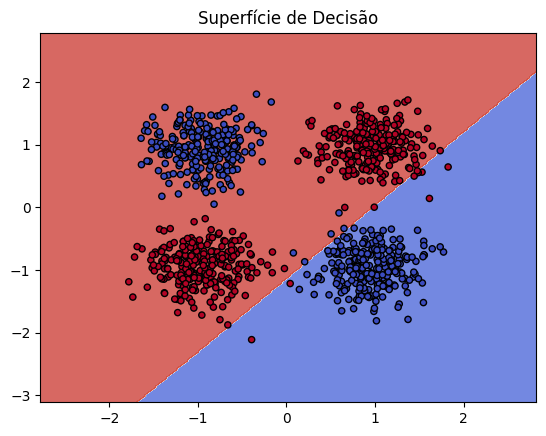

In [ ]:
pc.fit(X, Y) # realiza o aprendizado do modelo carregado em pc
plot_model(pc) # as funções acima para executar a classificação e exibir a linha de separaçao dos resultados

##MLP - Multilayer Perceptrons

In [ ]:
model = Sequential() # carrega um modelo feed-forward

model.add(Dense(4, input_dim=2)) #cria uma camada densa com com 4 neuronios e 2 entradas
model.add(Activation('tanh'))   #usando função de ativação tangente hiperbólica

model.add(Dense(2))  #cria uma camada densa com com 2 neuronios (que recebe as saídas da camada anterior)
model.add(Activation('softmax'))   #usando função de ativação softmax para definir qual é a classe na saída

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']) # define a rede neural

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#vamos separar o conjunto de treinamento e de testes
#30% para testes, o restante para treinamento

from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1000) # separa o conjunto de teste com 30% dos dados sorteados aleatóriamente com seed = 1000
#outros 70% são definidos no conjunto de teste

In [ ]:
#treinamento da rede neural
#usando 100 épocas

#método fit executa o treinamento
model.fit(X_train,  #para o conjunto de teste "train" onde x_train sao os atributos
          to_categorical(Y_train, num_classes=2),  #e y_train sao as classes
          epochs=100,  #em 100 épocas
          batch_size=32, #de 32 em 32
          validation_data=(X_test, to_categorical(Y_test, num_classes=2))) # e demonstrando a acurácia de teste com o conjunto "X_test e Y_test"

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5074 - loss: 0.7867 - val_accuracy: 0.4733 - val_loss: 0.8500
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5343 - loss: 0.7591 - val_accuracy: 0.4867 - val_loss: 0.8238
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5407 - loss: 0.7466 - val_accuracy: 0.5000 - val_loss: 0.8009
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5405 - loss: 0.7288 - val_accuracy: 0.5067 - val_loss: 0.7805
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5704 - loss: 0.7210 - val_accuracy: 0.5100 - val_loss: 0.7628
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5971 - loss: 0.6933 - val_accuracy: 0.5267 - val_loss: 0.7478
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6255 - loss: 0.6879 - val_accuracy: 0.5367 - val_loss: 0.7332
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6255 - loss: 0.6823 - val_accuracy: 0.5633 - 

In [ ]:
#verificação(predição) usando a base de teste
#qual seria a resposta da rede treinada se ela classificar os pontos que estao no conjunto de testes?

Y_eval_mlp = np.argmax(model.predict(X_test), axis=1) #retorna as classes definidas pelo modelo

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


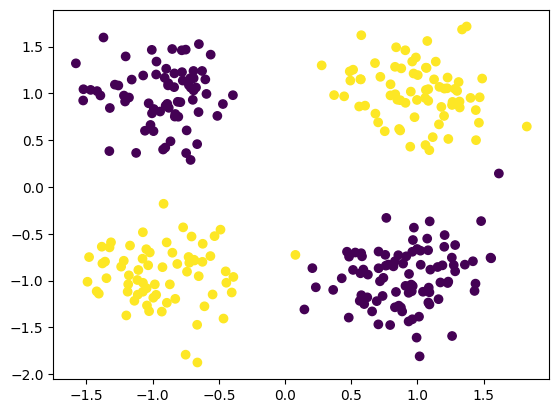

In [ ]:
#plotando os resultados
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico

##Superficie usando o modelo atual com tanh

In [ ]:
#para verificarmos os limites entre os conjuntos de classificação
#vamos criar um conjunto com muitos pontos gerados aleatóriamente
#e usar o modelo para definir qual seria sua classe

Xm = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada X
Ym = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada Y
Xmg, Ymg = np.meshgrid(Xm, Ym)  #retorna as coordenadas da grade 2-D com base nas coordenadas contidas nos vetores x e y
X_eval = np.vstack([Xmg.ravel(), Ymg.ravel()]).T #cria o conjunto de entradas para as coordenadas geradas

Y_eval_mlp = np.argmax(model.predict(X_eval), axis=1) # usa o modelo carregado em model para realizar a classificação

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 39s 1ms/step


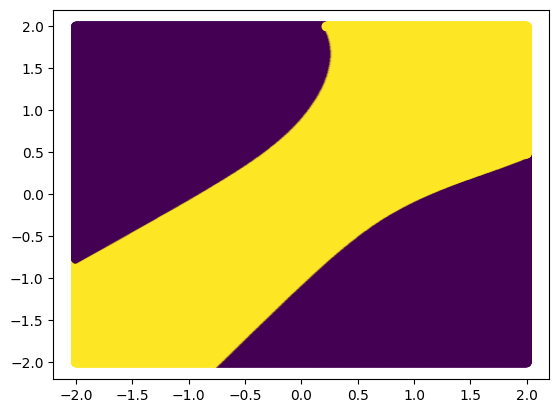

In [ ]:
#plotando os resultados
plt.scatter(X_eval[:, 0], X_eval[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico

## Criando um modelo usando função de ativação Relu

In [ ]:
#para isto, vamos reproduzir a mesma rede neural anterior
#mas mudando a função de ativação

model = Sequential() # carrega um modelo feed-forward

model.add(Dense(4, input_dim=2)) #cria uma camada densa com com 4 neuronios e 2 entradas
model.add(Activation('relu'))   #usando função de ativação relu

model.add(Dense(2))  #cria uma camada densa com com 2 neuronios (que recebe as saídas da camada anterior)
model.add(Activation('softmax'))   #usando função de ativação softmax para definir qual é a classe na saída

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']) # define a rede neural

In [ ]:
#vamos separar o conjunto de treinamento e de testes
#30% para testes, o restante para treinamento

from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1000) # separa o conjunto de teste com 30% dos dados sorteados aleatóriamente com seed = 1000
#outros 70% são definidos no conjunto de teste

#treinamento da rede neural
#usando 100 épocas

#método fit executa o treinamento
model.fit(X_train,  #para o conjunto de teste "train" onde x_train sao os atributos
          to_categorical(Y_train, num_classes=2),  #e y_train sao as classes
          epochs=100,  #em 100 épocas
          batch_size=32, #de 32 em 32
          validation_data=(X_test, to_categorical(Y_test, num_classes=2))) # e demonstrando a acurácia de teste com o conjunto "X_test e Y_test"

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4097 - loss: 0.6904 - val_accuracy: 0.4333 - val_loss: 0.6404
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4798 - loss: 0.6359 - val_accuracy: 0.5100 - val_loss: 0.6061
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6055 - loss: 0.5733 - val_accuracy: 0.5833 - val_loss: 0.5808
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6624 - loss: 0.5595 - val_accuracy: 0.6300 - val_loss: 0.5608
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7024 - loss: 0.5274 - val_accuracy: 0.6533 - val_loss: 0.5455
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6982 - loss: 0.5308 - val_accuracy: 0.6567 - val_loss: 0.5333
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7501 - loss: 0.4901 - val_accuracy: 0.6600 - val_loss: 0.5231
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7308 - loss: 0.4866 - val_accuracy: 0.6600 - 

In [ ]:
#verificação(predição) usando a base de teste
#qual seria a resposta da rede treinada se ela classificar os pontos que estao no conjunto de testes?

Y_eval_mlp = np.argmax(model.predict(X_test), axis=1) #retorna as classes definidas pelo modelo

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


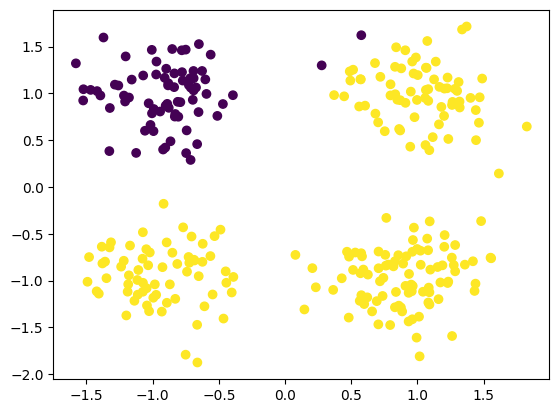

In [ ]:
#plotando os resultados
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico

In [ ]:
#vamos criar um conjunto com muitos pontos gerados aleatóriamente
#e usar o modelo para definir qual seria sua classe

Xm = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada X
Ym = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada Y
Xmg, Ymg = np.meshgrid(Xm, Ym)  #retorna as coordenadas da grade 2-D com base nas coordenadas contidas nos vetores x e y
X_eval = np.vstack([Xmg.ravel(), Ymg.ravel()]).T #cria o conjunto de entradas para as coordenadas geradas

Y_eval_mlp = np.argmax(model.predict(X_eval), axis=1) # usa o modelo carregado em model para realizar a classificação

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 35s 1ms/step


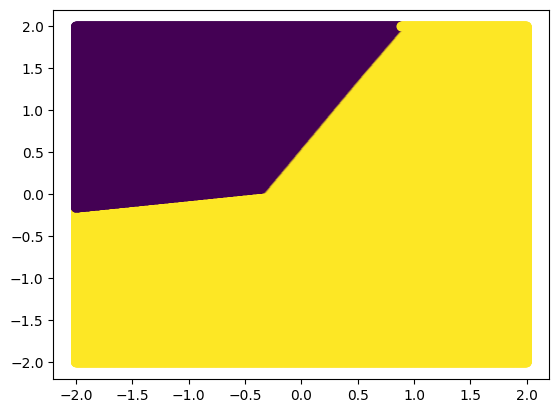

In [ ]:
#plotando os resultados
plt.scatter(X_eval[:, 0], X_eval[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico